<a href="https://colab.research.google.com/github/Pratham73/Machine-Learning/blob/main/Spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [22]:
df = pd.read_csv("/content/spam.csv", encoding='latin-1')
df = df.rename(columns={'v1': 'label', 'v2': 'message'})
df = df[['label', 'message']]
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

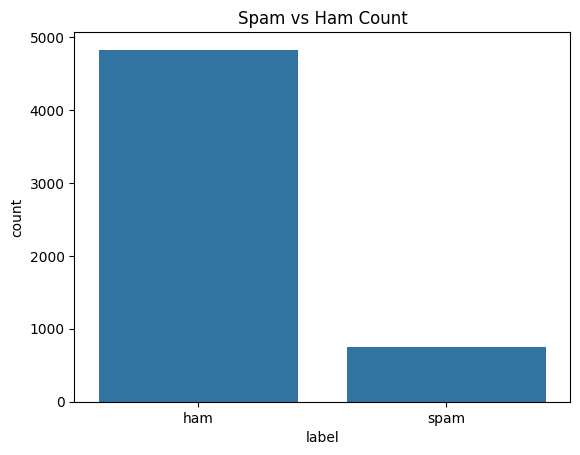

In [23]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Count")
plt.show()

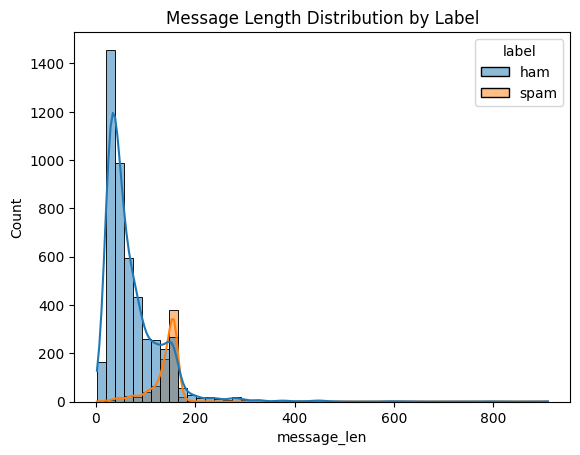

In [24]:
df['message_len'] = df['message'].apply(len)
sns.histplot(data=df, x='message_len', hue='label', bins=50, kde=True)
plt.title("Message Length Distribution by Label")
plt.show()

In [26]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['message'])
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

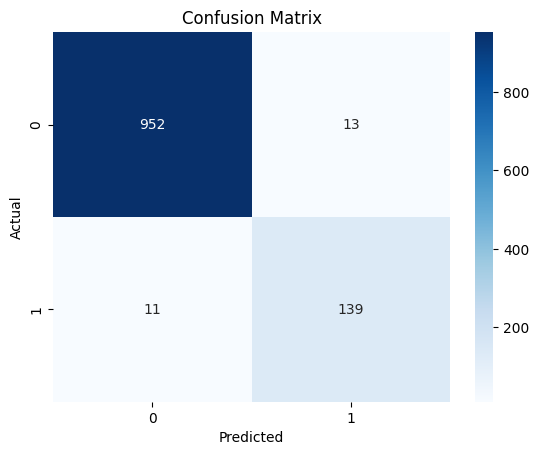

In [28]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print(classification_report(y_test, y_pred))

Accuracy: 0.97847533632287
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115

